# CEF deep-dive: Oxford Lane at the center

Thin driver notebook: all logic lives in `src/cef/`. Framing: listed CLO closed-end funds (Oxford Lane Capital Corp., OXLC, at the center; Eagle Point Credit, ECC, alongside) are **permanent capital that converts retail demand into primary CLO equity orders** — their capital formation is upstream of CLO formation.

**The centerpiece — the premium-funded ATM flywheel** (`analysis_capital_machine.py`, `viz_flywheel.py`): OXLC's own EDGAR 424B3/497 prospectus supplements disclose, in plain sentences, exactly how many ATM shares were sold and at what proceeds since the last supplement, *and* a preliminary NAV-per-share estimate at scattered month-ends. Joining those against OXLC's market price gives a **real historical premium/discount series** — richer than Section 2's own premium/discount table, which is limited to a single current-day book-value snapshot (yfinance has no historical NAV for these tickers).

**A real bug, caught and fixed along the way**: OXLC underwent a 1-for-5 reverse split on 2025-09-08. Yahoo Finance's historical "Close" price turned out to be retroactively split-adjusted (not just dividend-adjusted, despite the naming), while the scraped NAV disclosures were not — the first pass through this pipeline produced a nonsense 813% "premium" for April 2020 before the mismatch was traced and fixed (`scrape_preferreds.scrape_stock_splits`, `analysis_capital_machine._cumulative_split_factor`; regression test in `tests/test_analysis_capital_machine.py`).

**Extends into**: cost of capital (preferred/baby-bond yields vs. portfolio effective yield), distribution-cut resilience (does the premium survive a cut?), portfolio shelf/vintage concentration (NPORT-P), the NAV-translation leverage gradient (JAAA -> BKLN -> OXLC/ECC, teaching the whole capital structure through instruments a desk can quote), and a 13G-based institutional-ownership floor.

**Documented gap**: the demand-transmission chain's final link (issuance -> market-wide CLO new-issue equity conditions) needs Section 4's CLO issuance-cycle data, which is empty (SIFMA gated) — reported as a gap in `analysis_demand_transmission.py`, not silently dropped.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.cef import (
    scrape_capital_actions, scrape_preferreds, scrape_13f_ownership,
    analysis_capital_machine, analysis_cost_of_capital, analysis_distribution_quality,
    analysis_portfolio_style, analysis_nav_translation, analysis_ownership, analysis_demand_transmission,
    viz_flywheel, viz_cost_of_capital, viz_distribution, viz_style, viz_wrapper,
    ledger,
)


/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_capital_actions.run()   # ATM tape, preferred series, NAV disclosures — from EDGAR 424B3/497
    scrape_preferreds.run()        # preferred/baby-bond prices + stock-split history
    scrape_13f_ownership.run()     # Schedule 13G/13G-A


## Analysis (interim -> final)

In [3]:
capital_machine = analysis_capital_machine.run()
cost_of_capital = analysis_cost_of_capital.run()
distribution_quality = analysis_distribution_quality.run()
portfolio_style = analysis_portfolio_style.run()
nav_translation = analysis_nav_translation.run()
ownership = analysis_ownership.run()
demand_transmission = analysis_demand_transmission.run()


## Viz (final -> figures/)

/Users/zinuoshi/clo-atlas/src/cef/viz_wrapper.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([LABELS[t] for t in merged["ticker"]], fontsize=8.5)
/Users/zinuoshi/clo-atlas/src/cef/viz_wrapper.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([LABELS[t] for t in merged["ticker"]], fontsize=8.5)


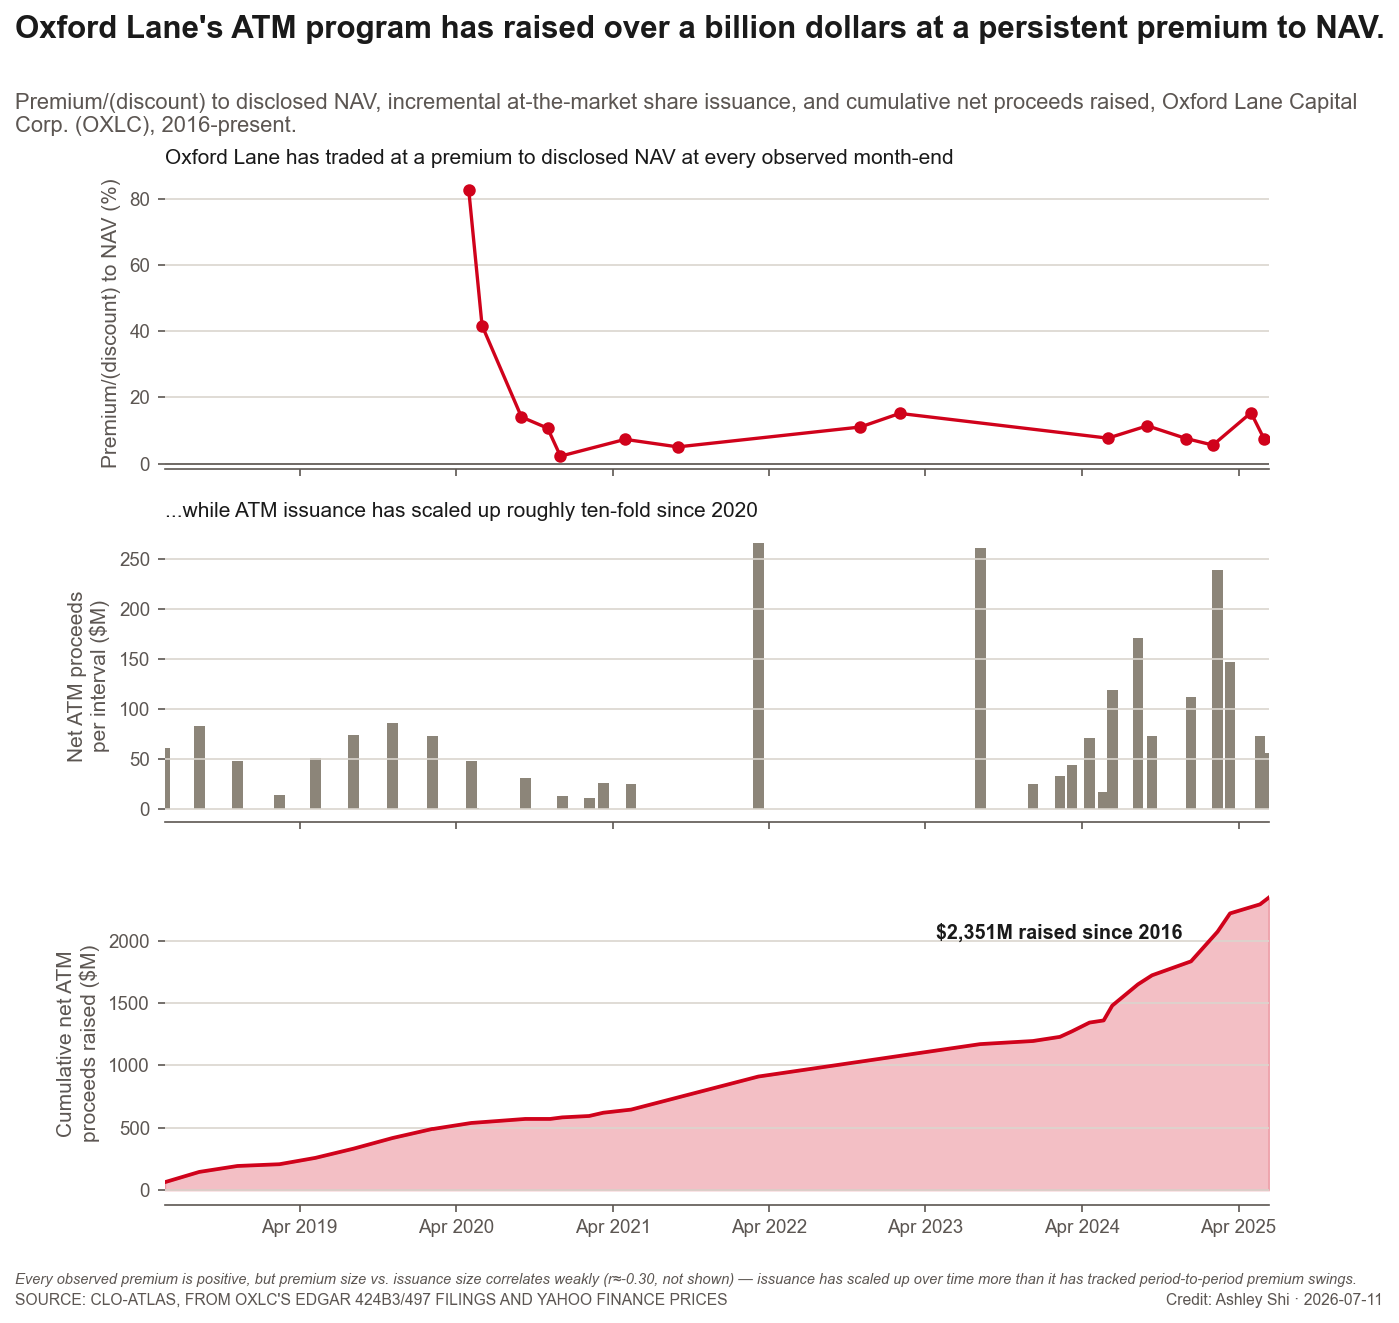

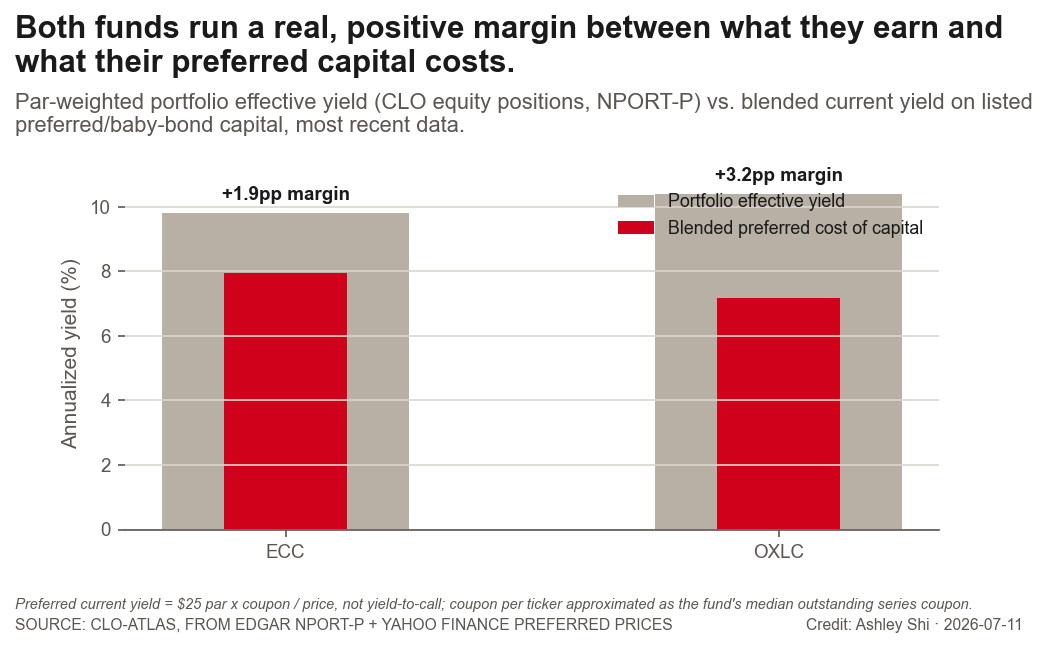

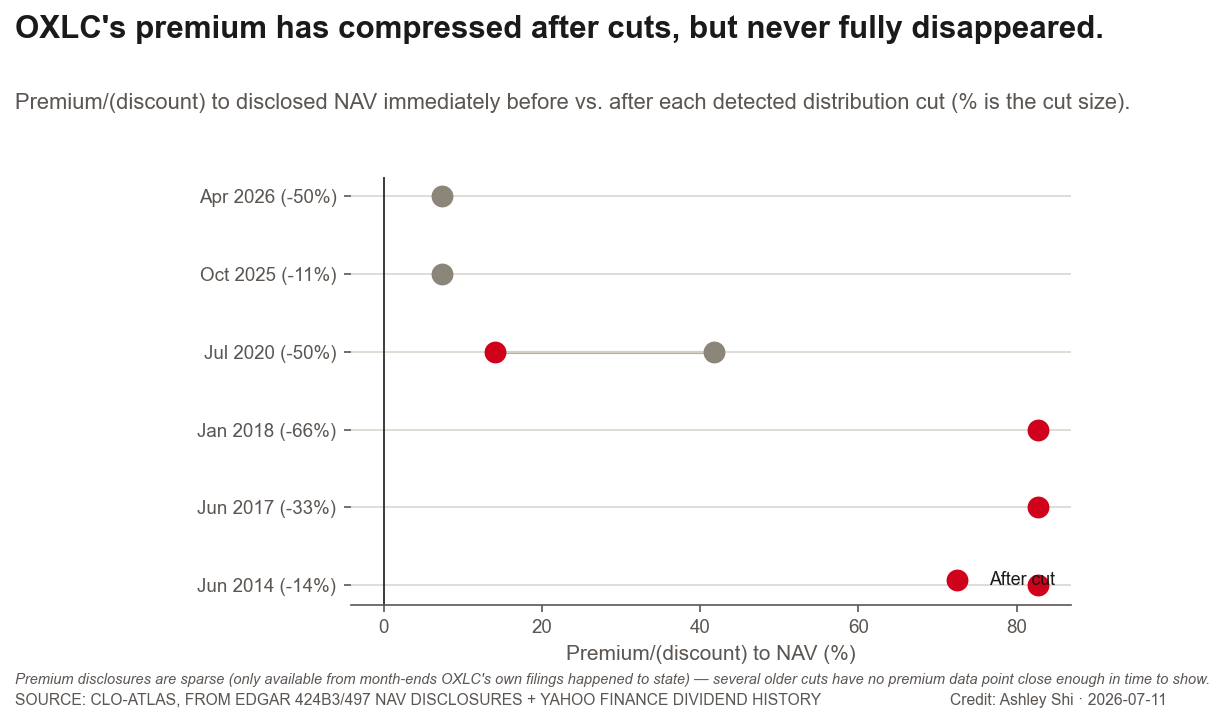

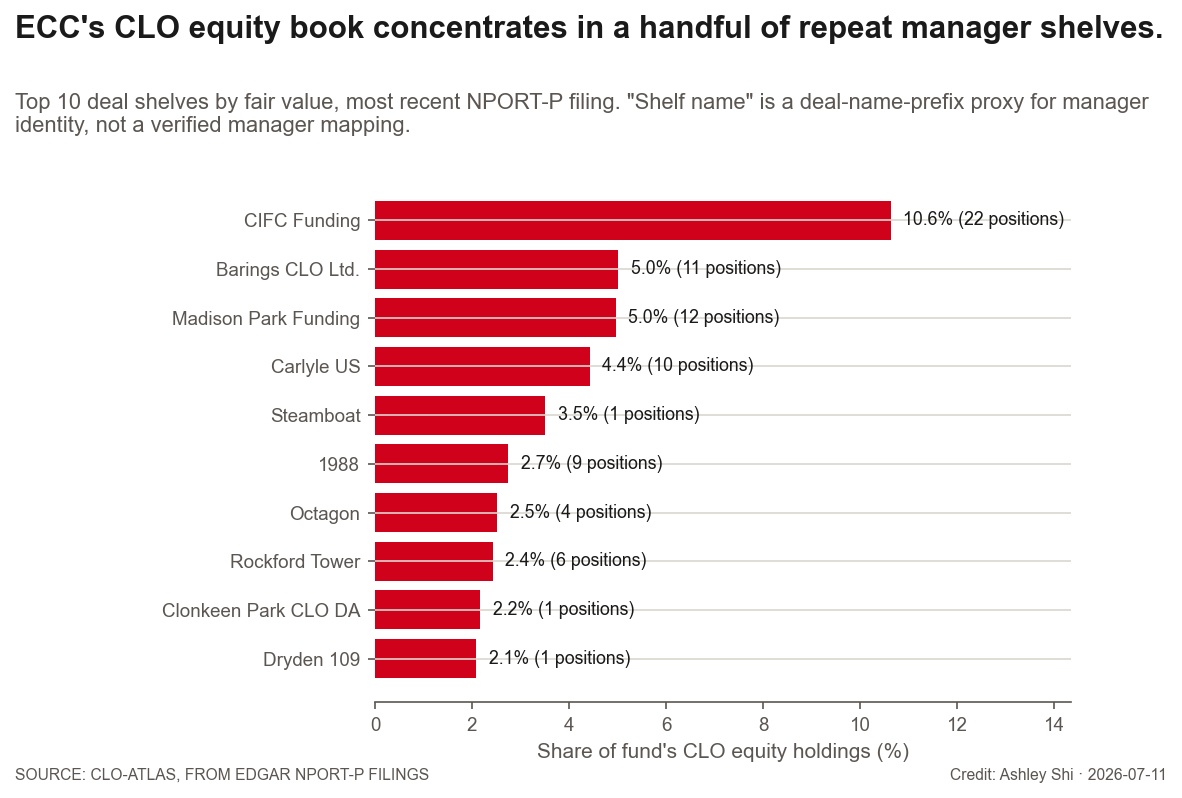

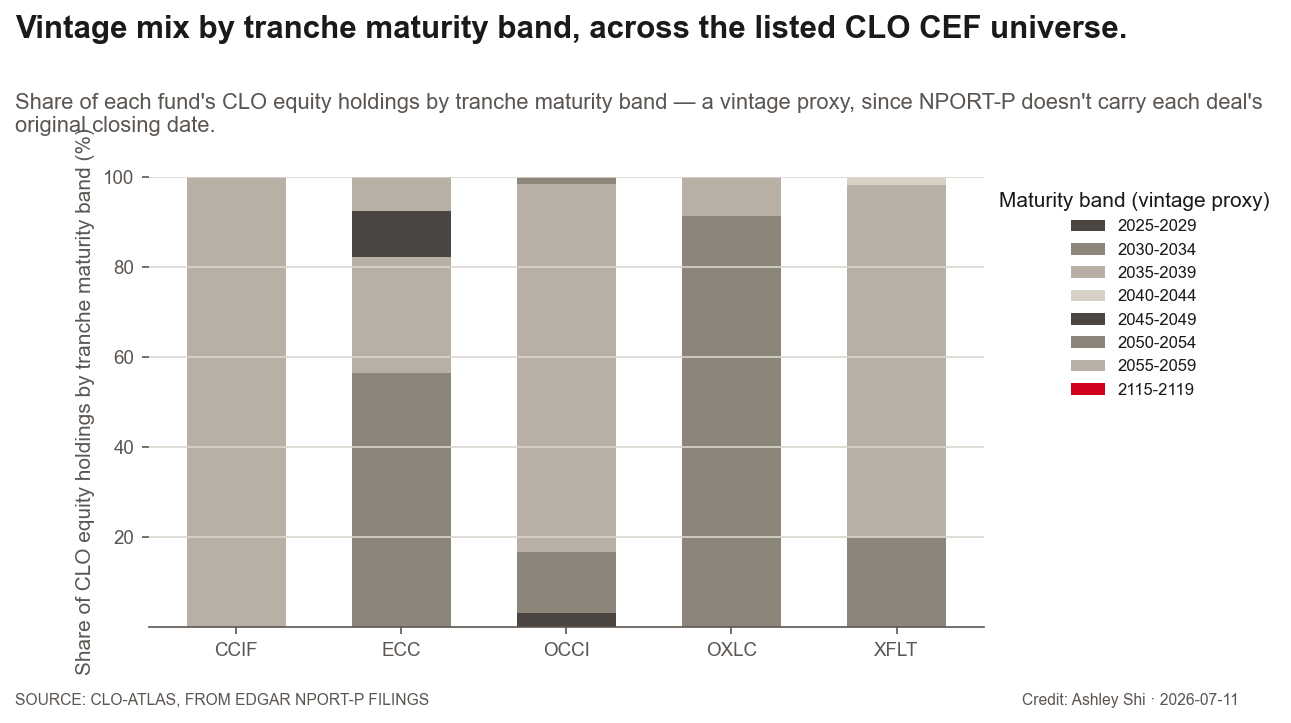

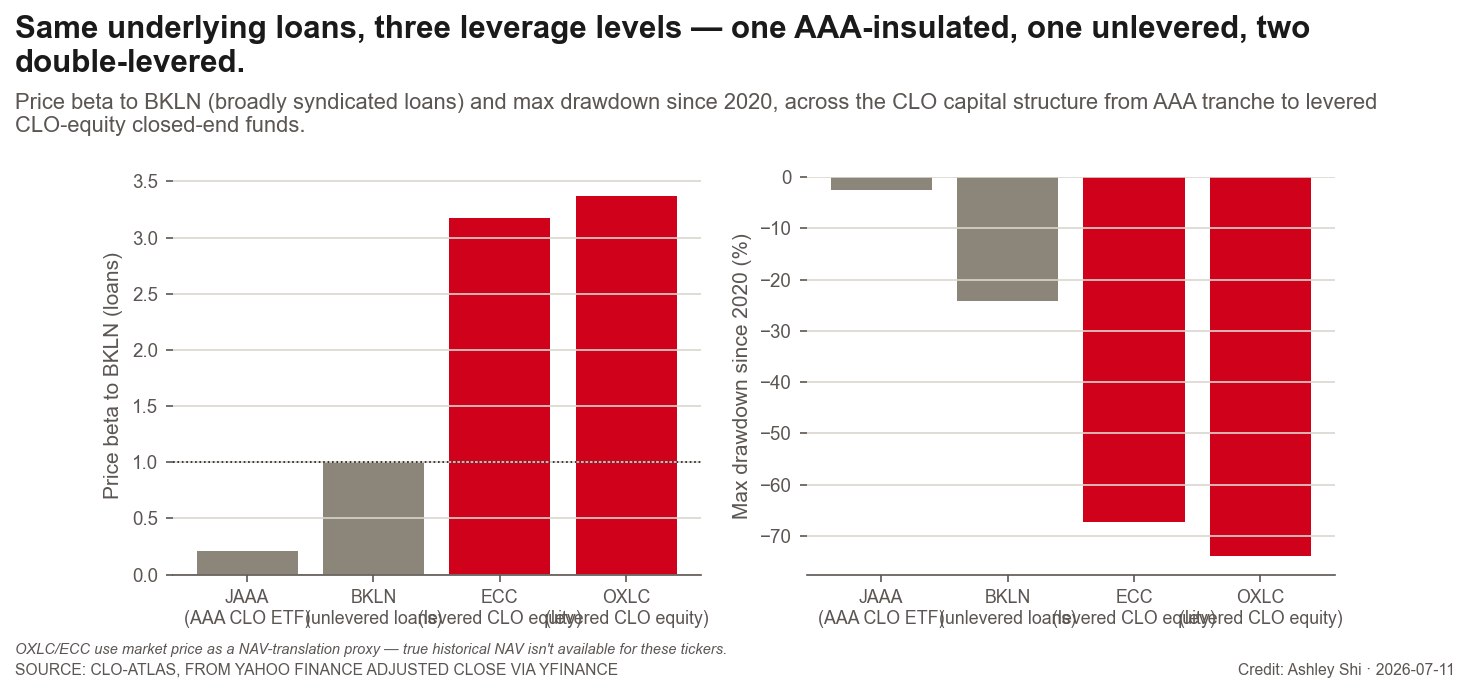

In [4]:
viz_flywheel.run()
viz_cost_of_capital.run()
viz_distribution.run()
viz_style.run()
viz_wrapper.run()


## Exhibits

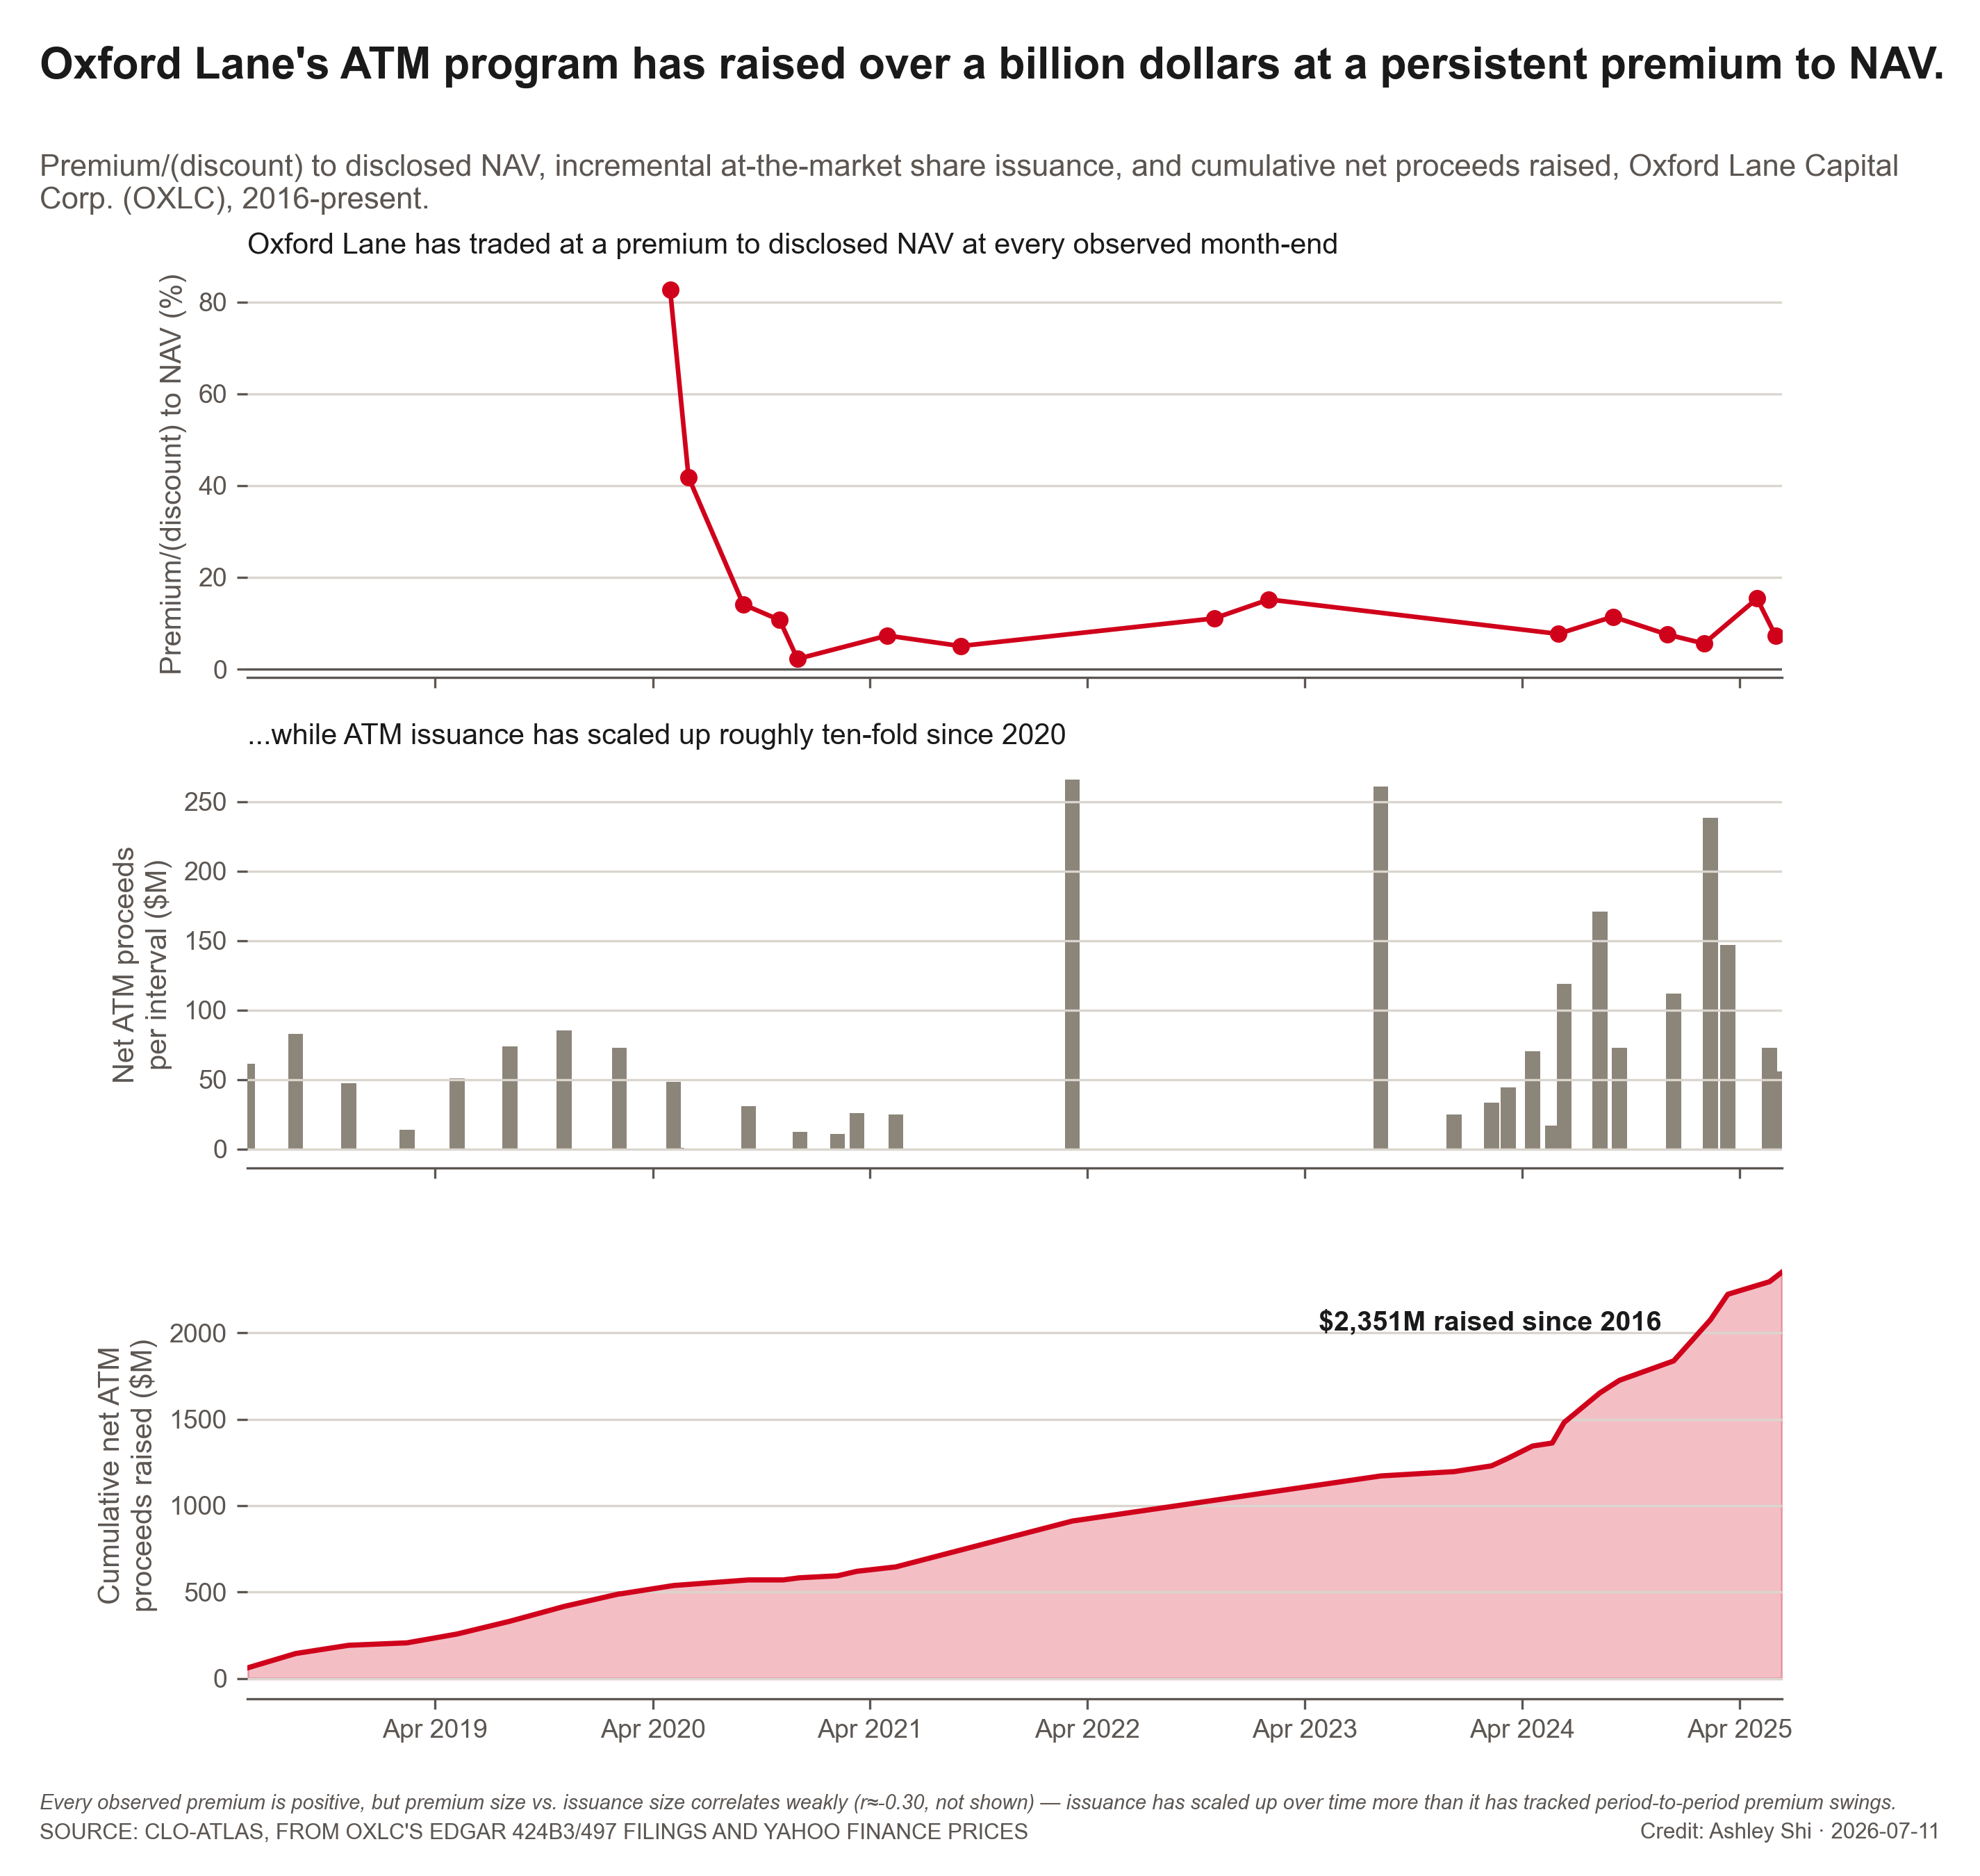

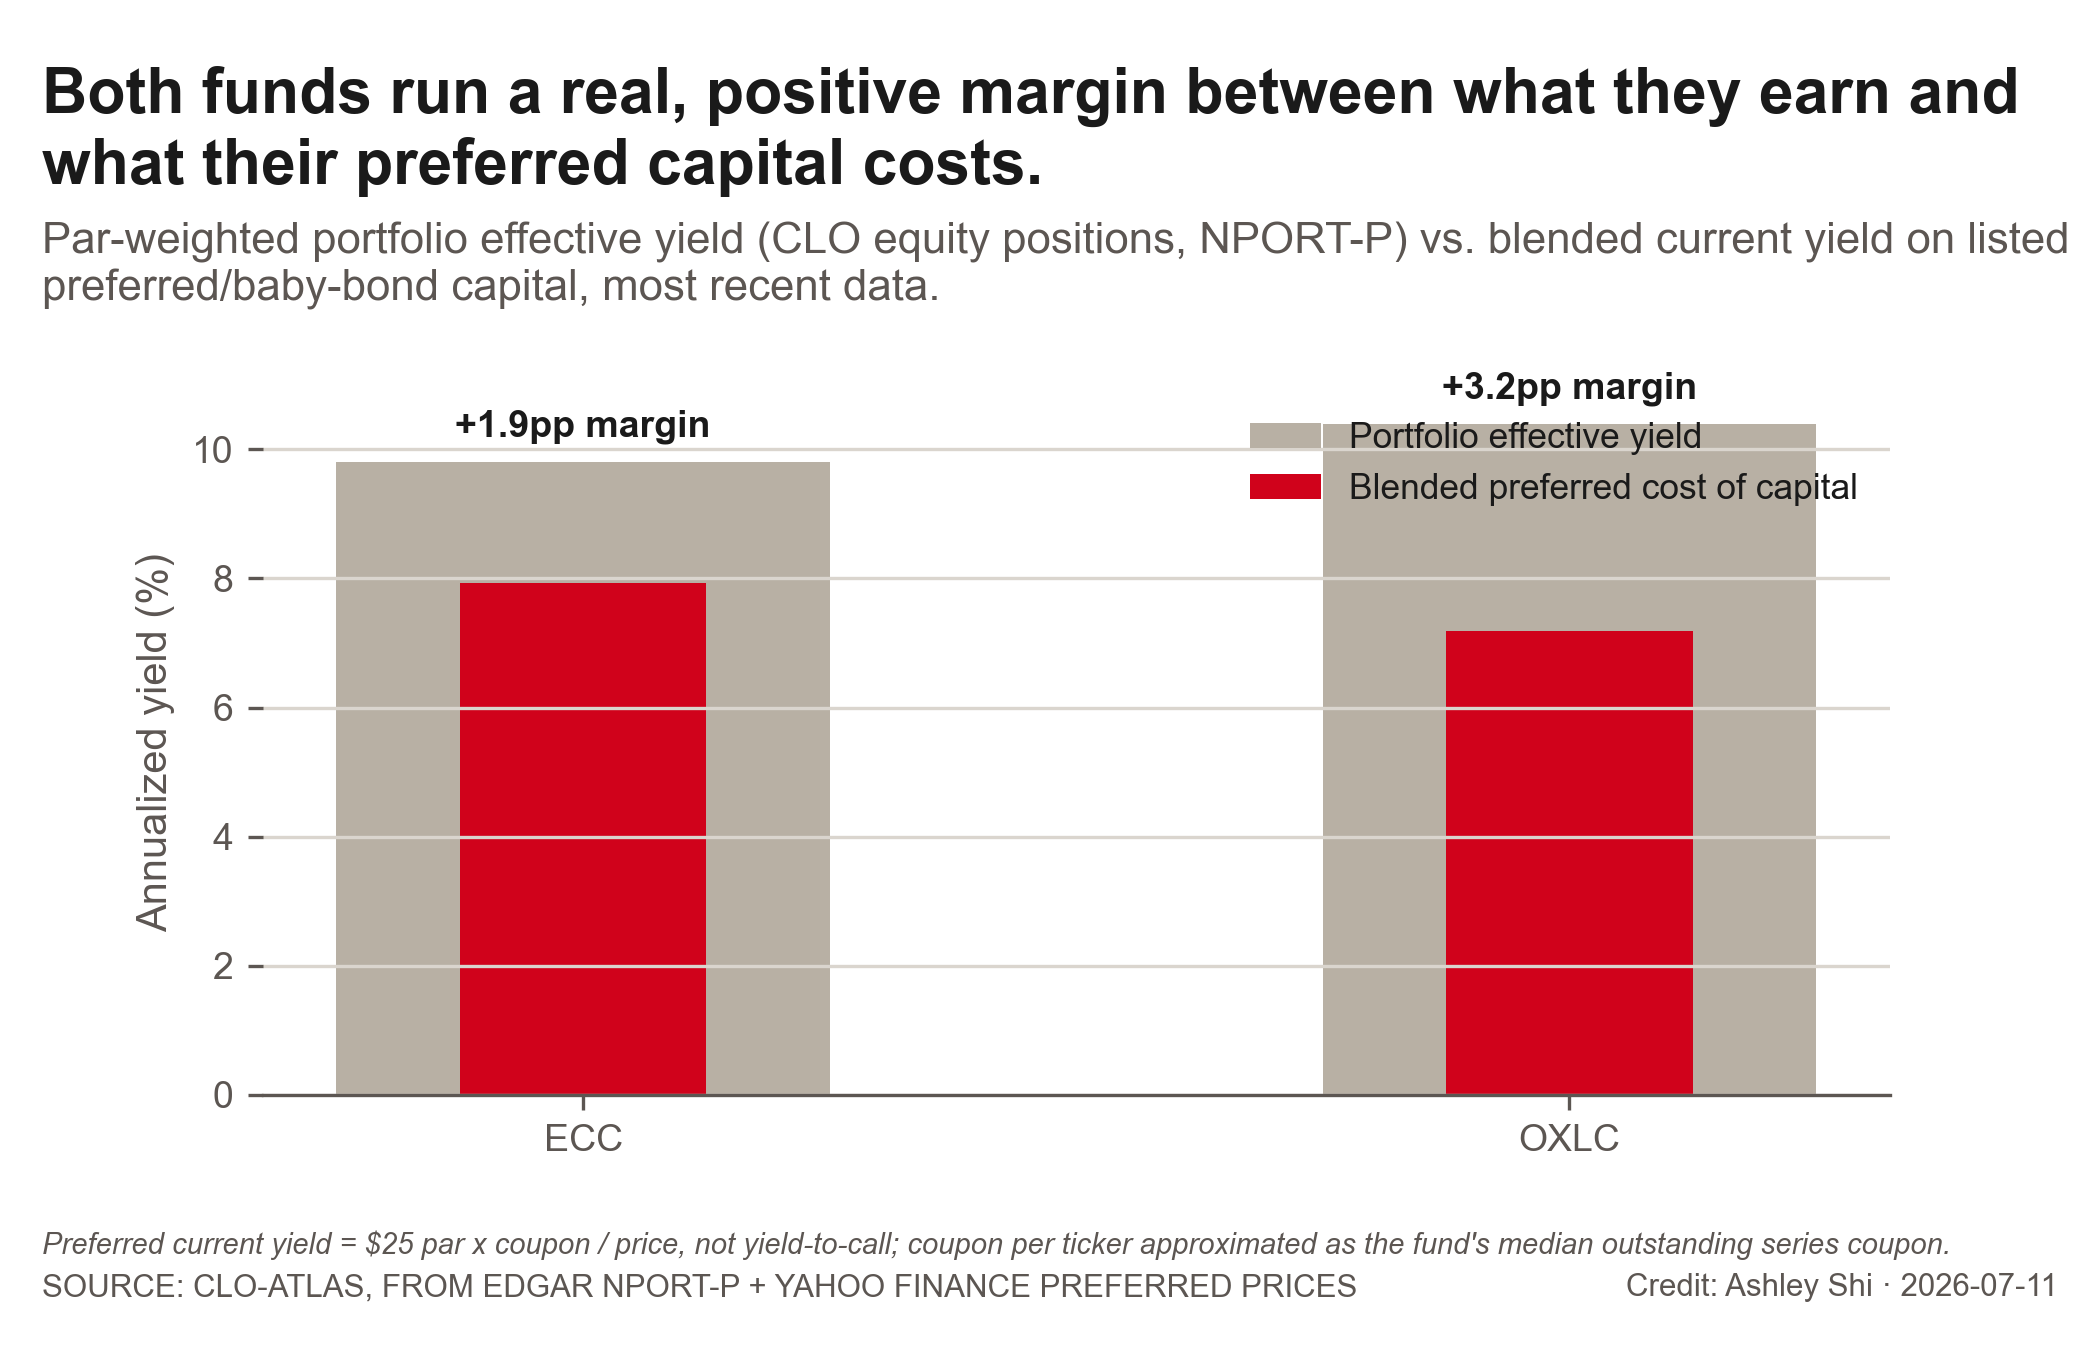

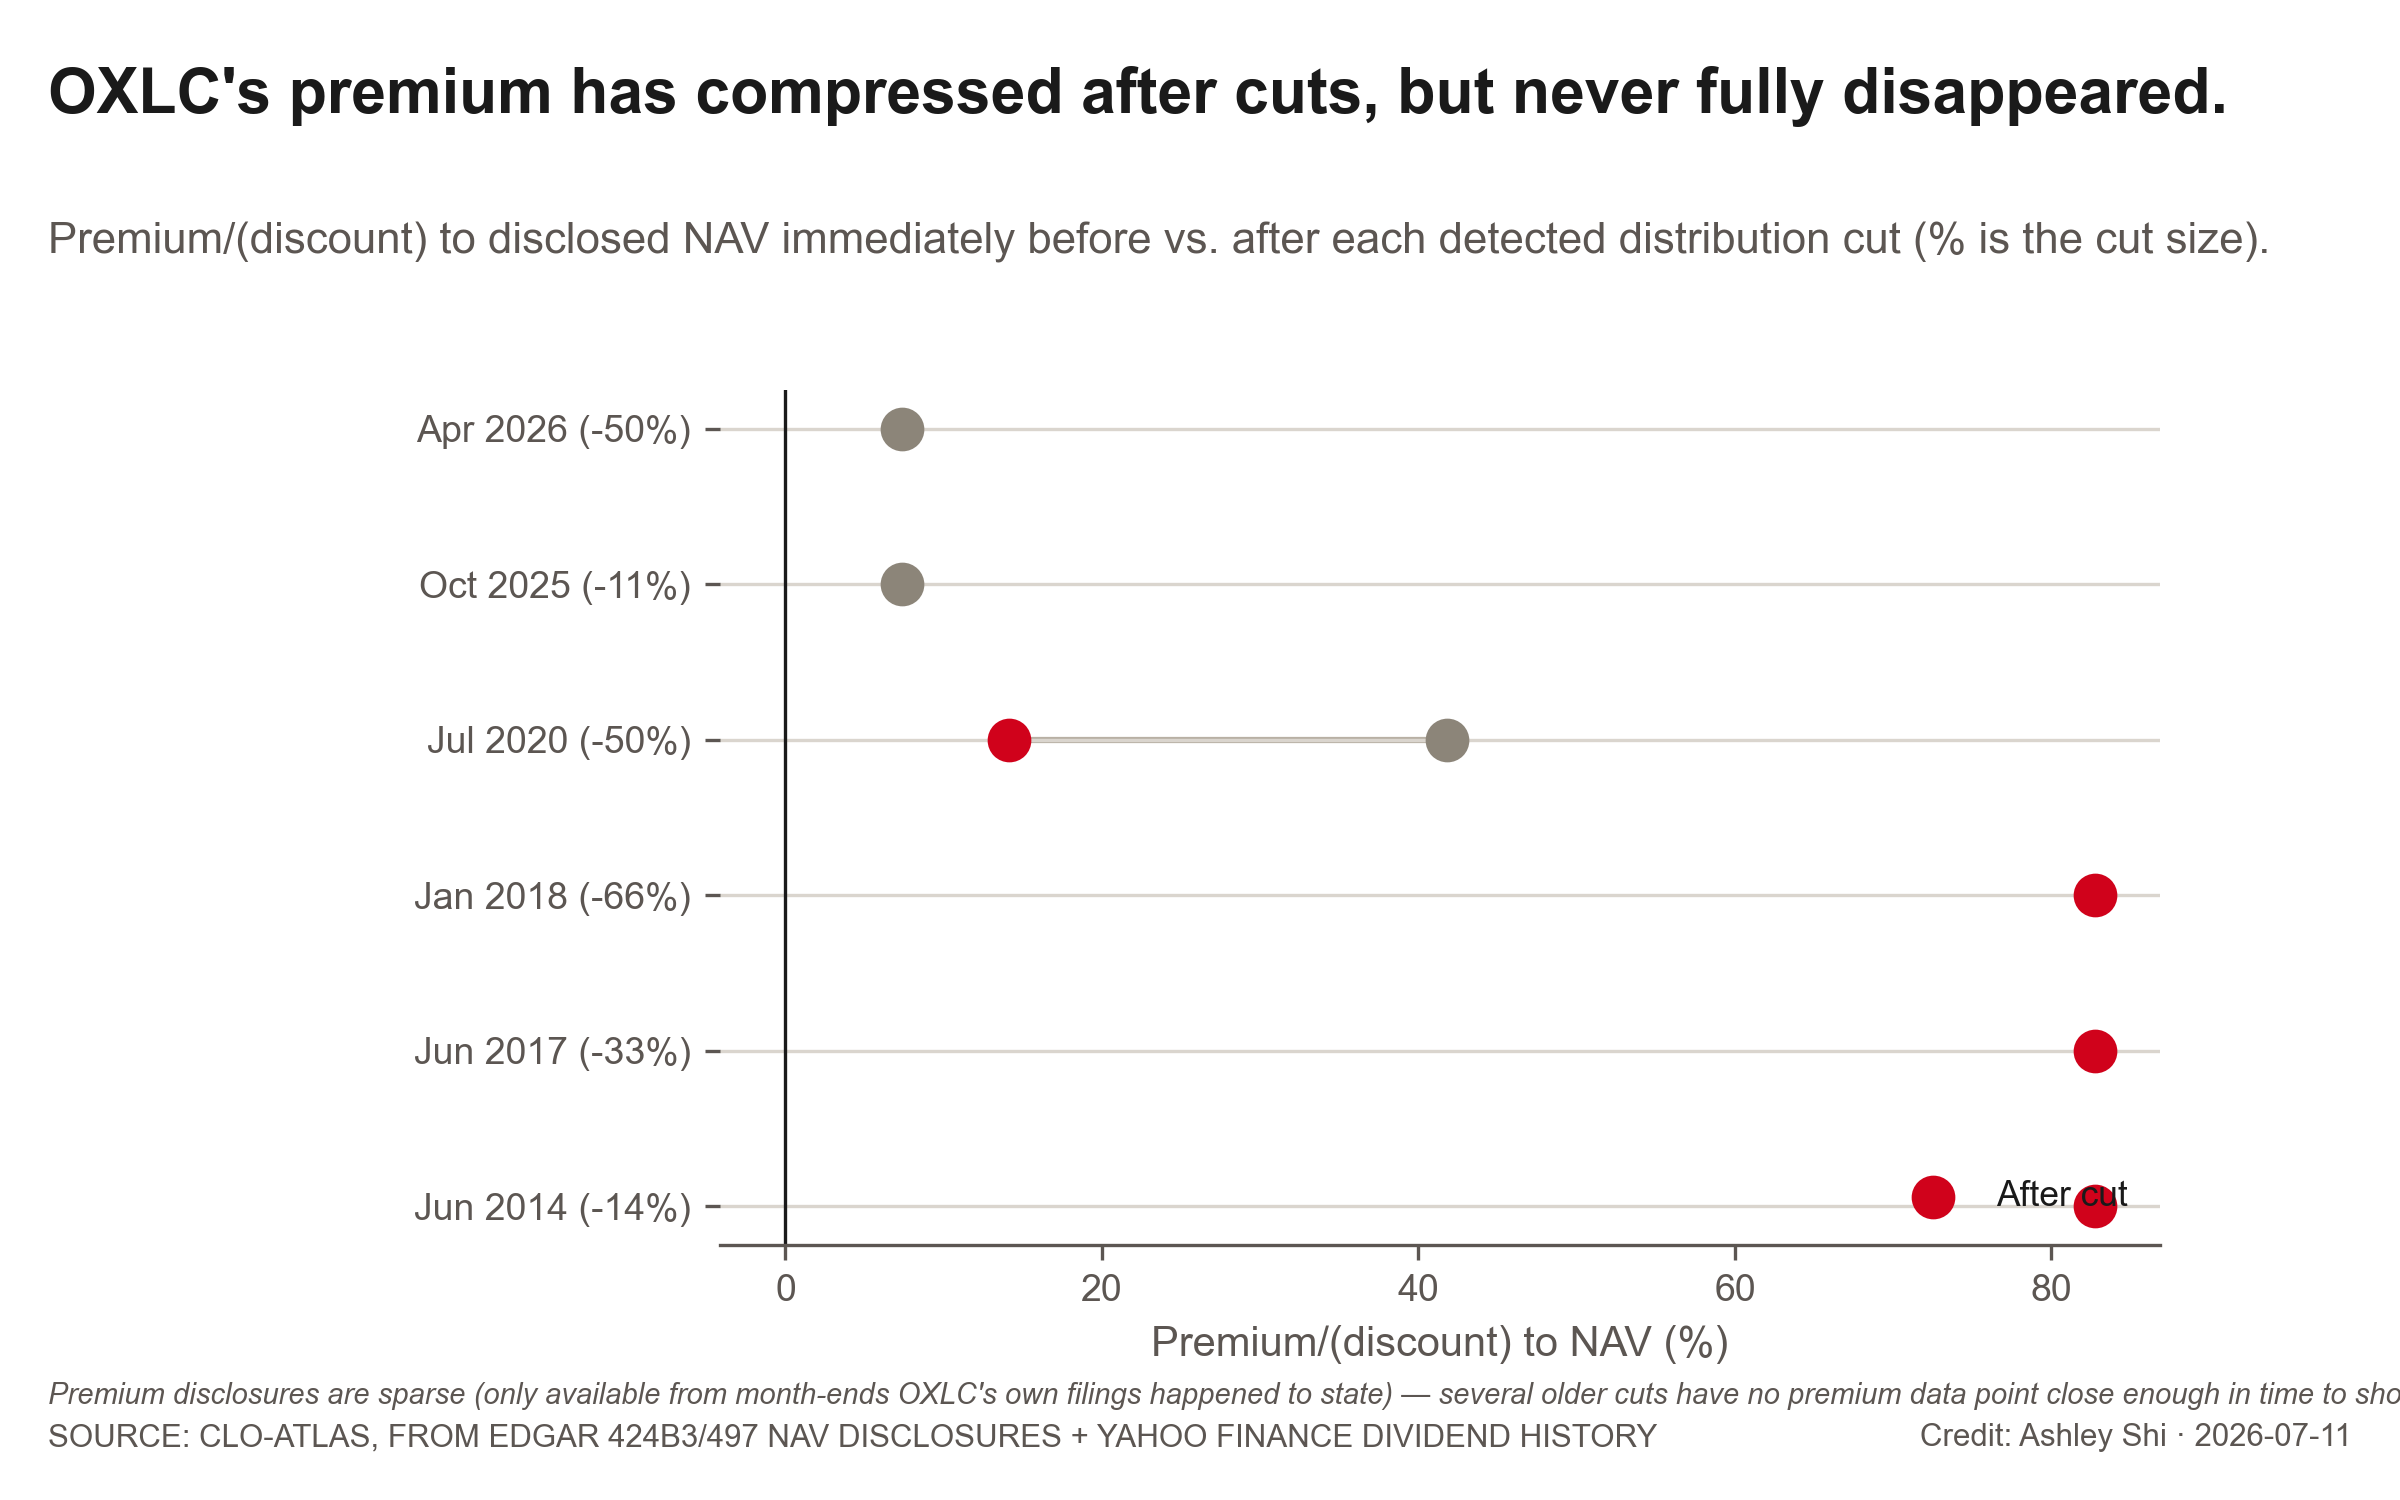

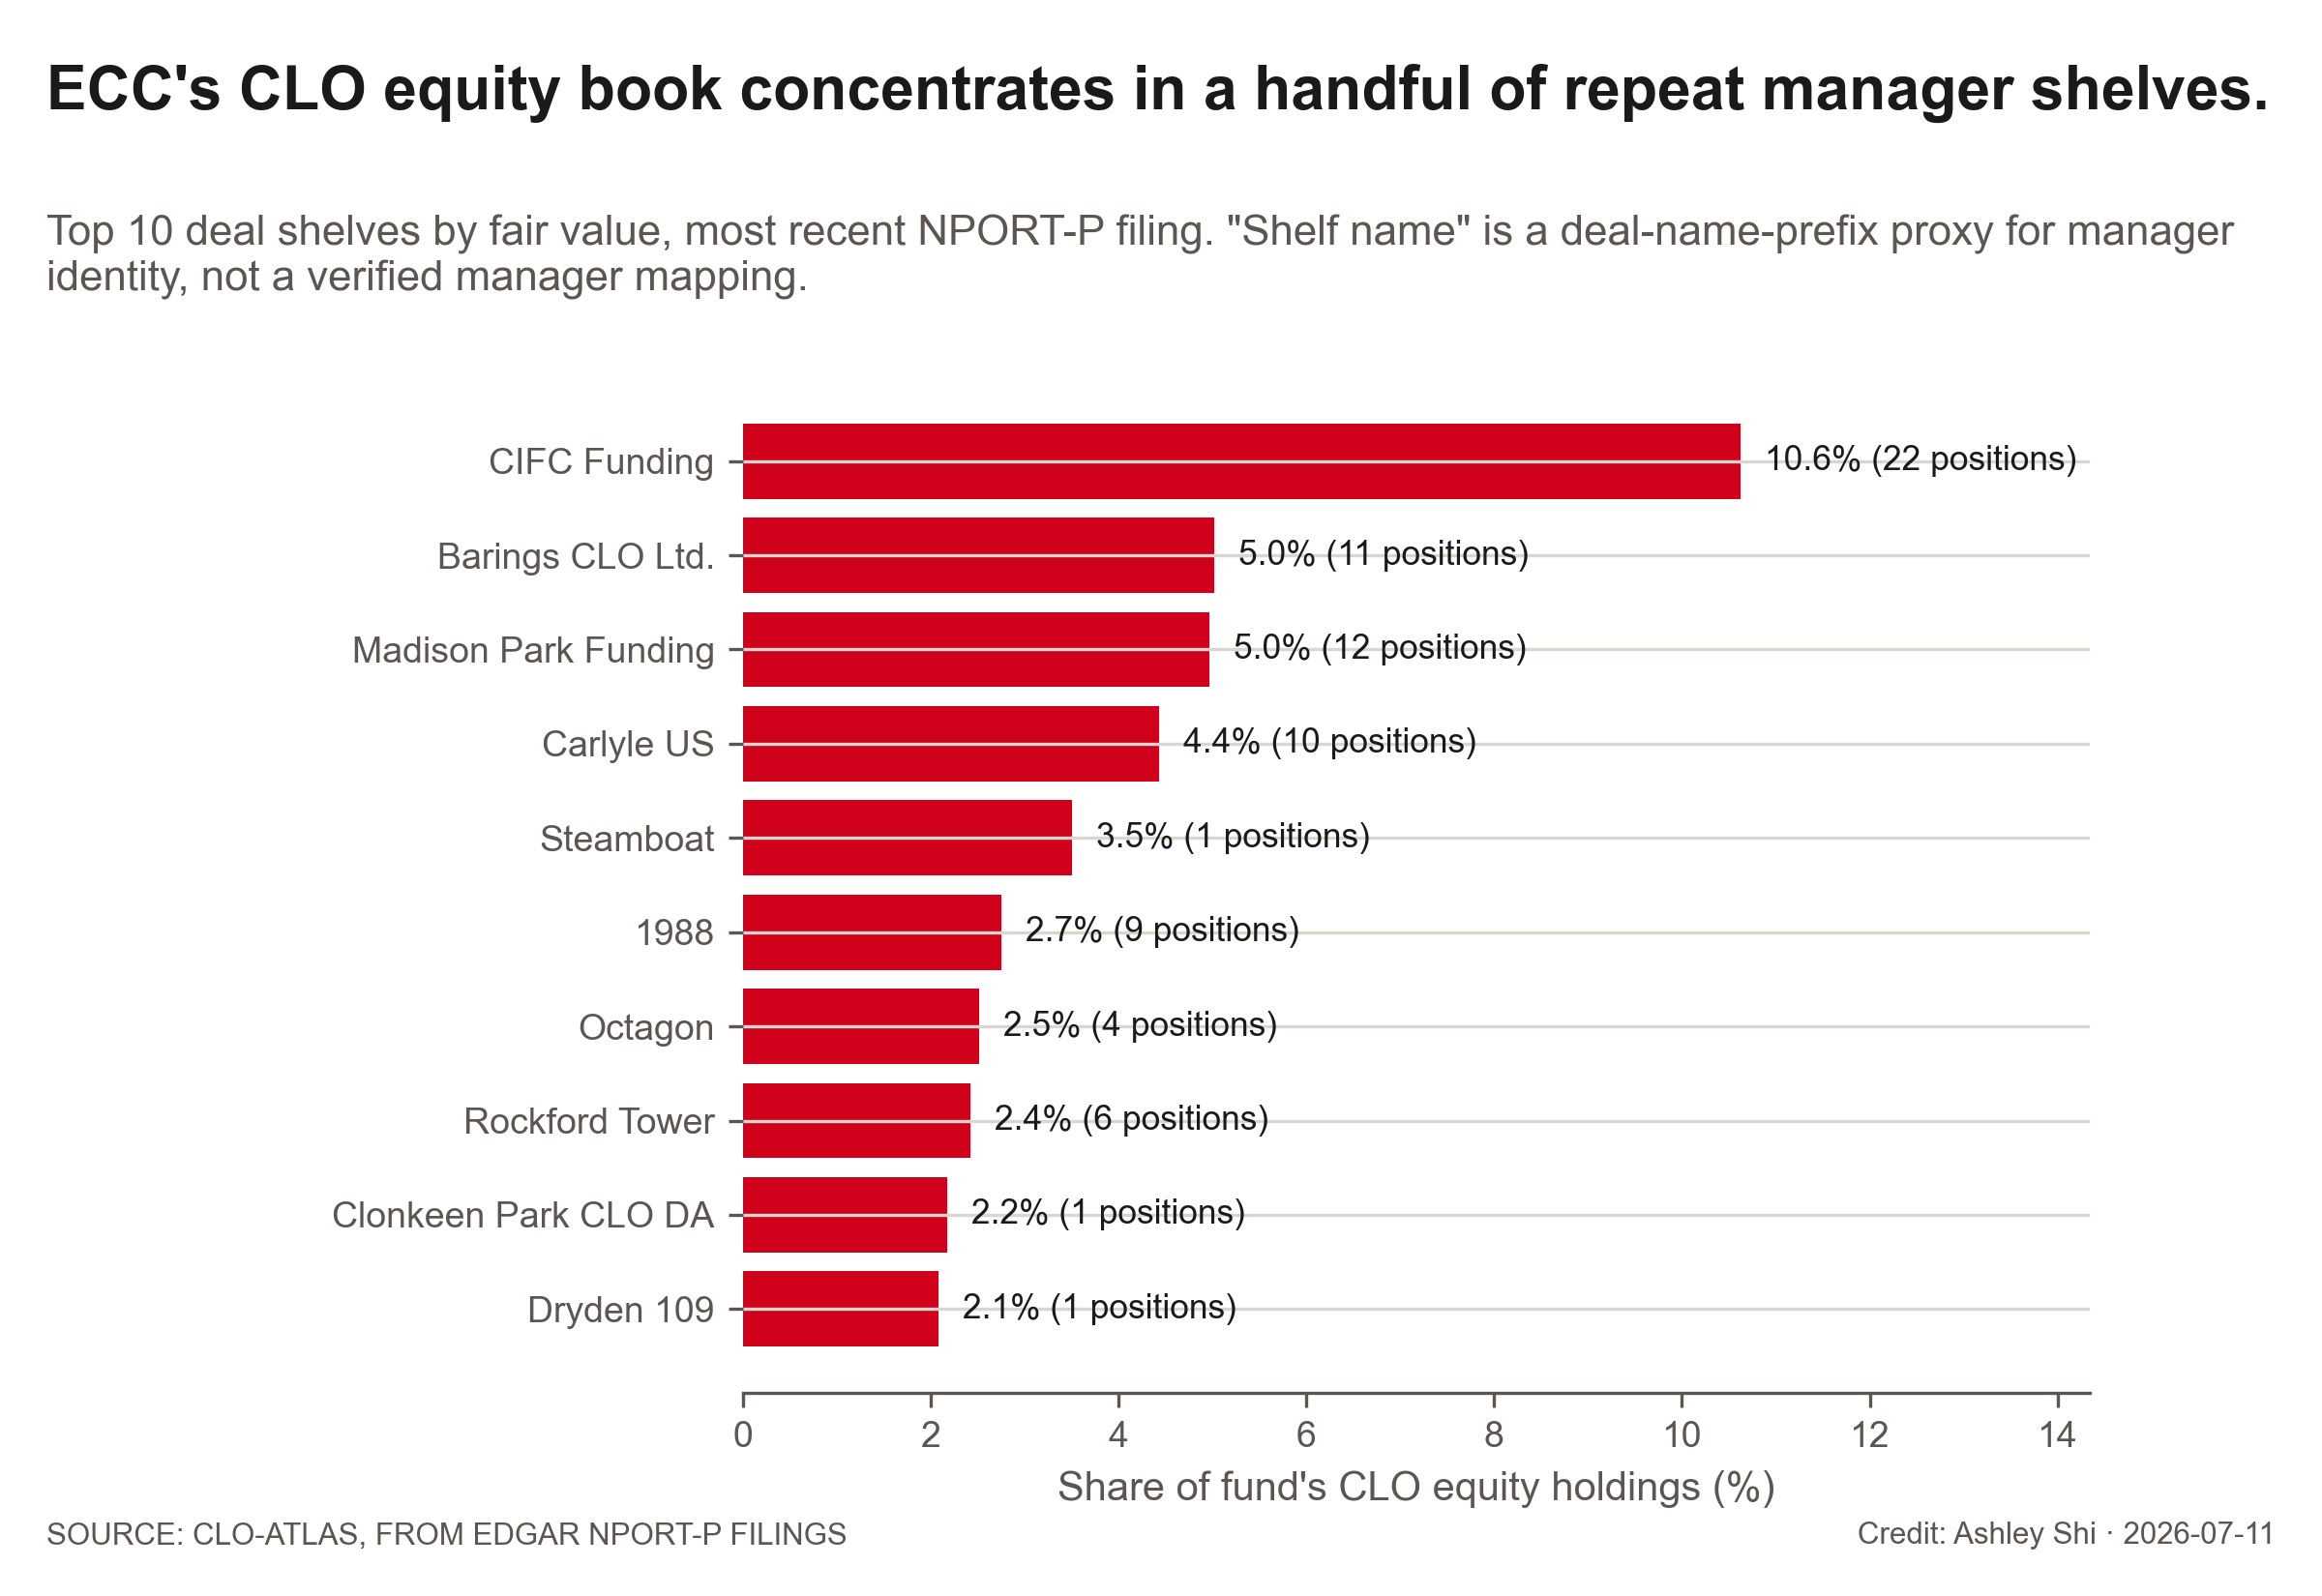

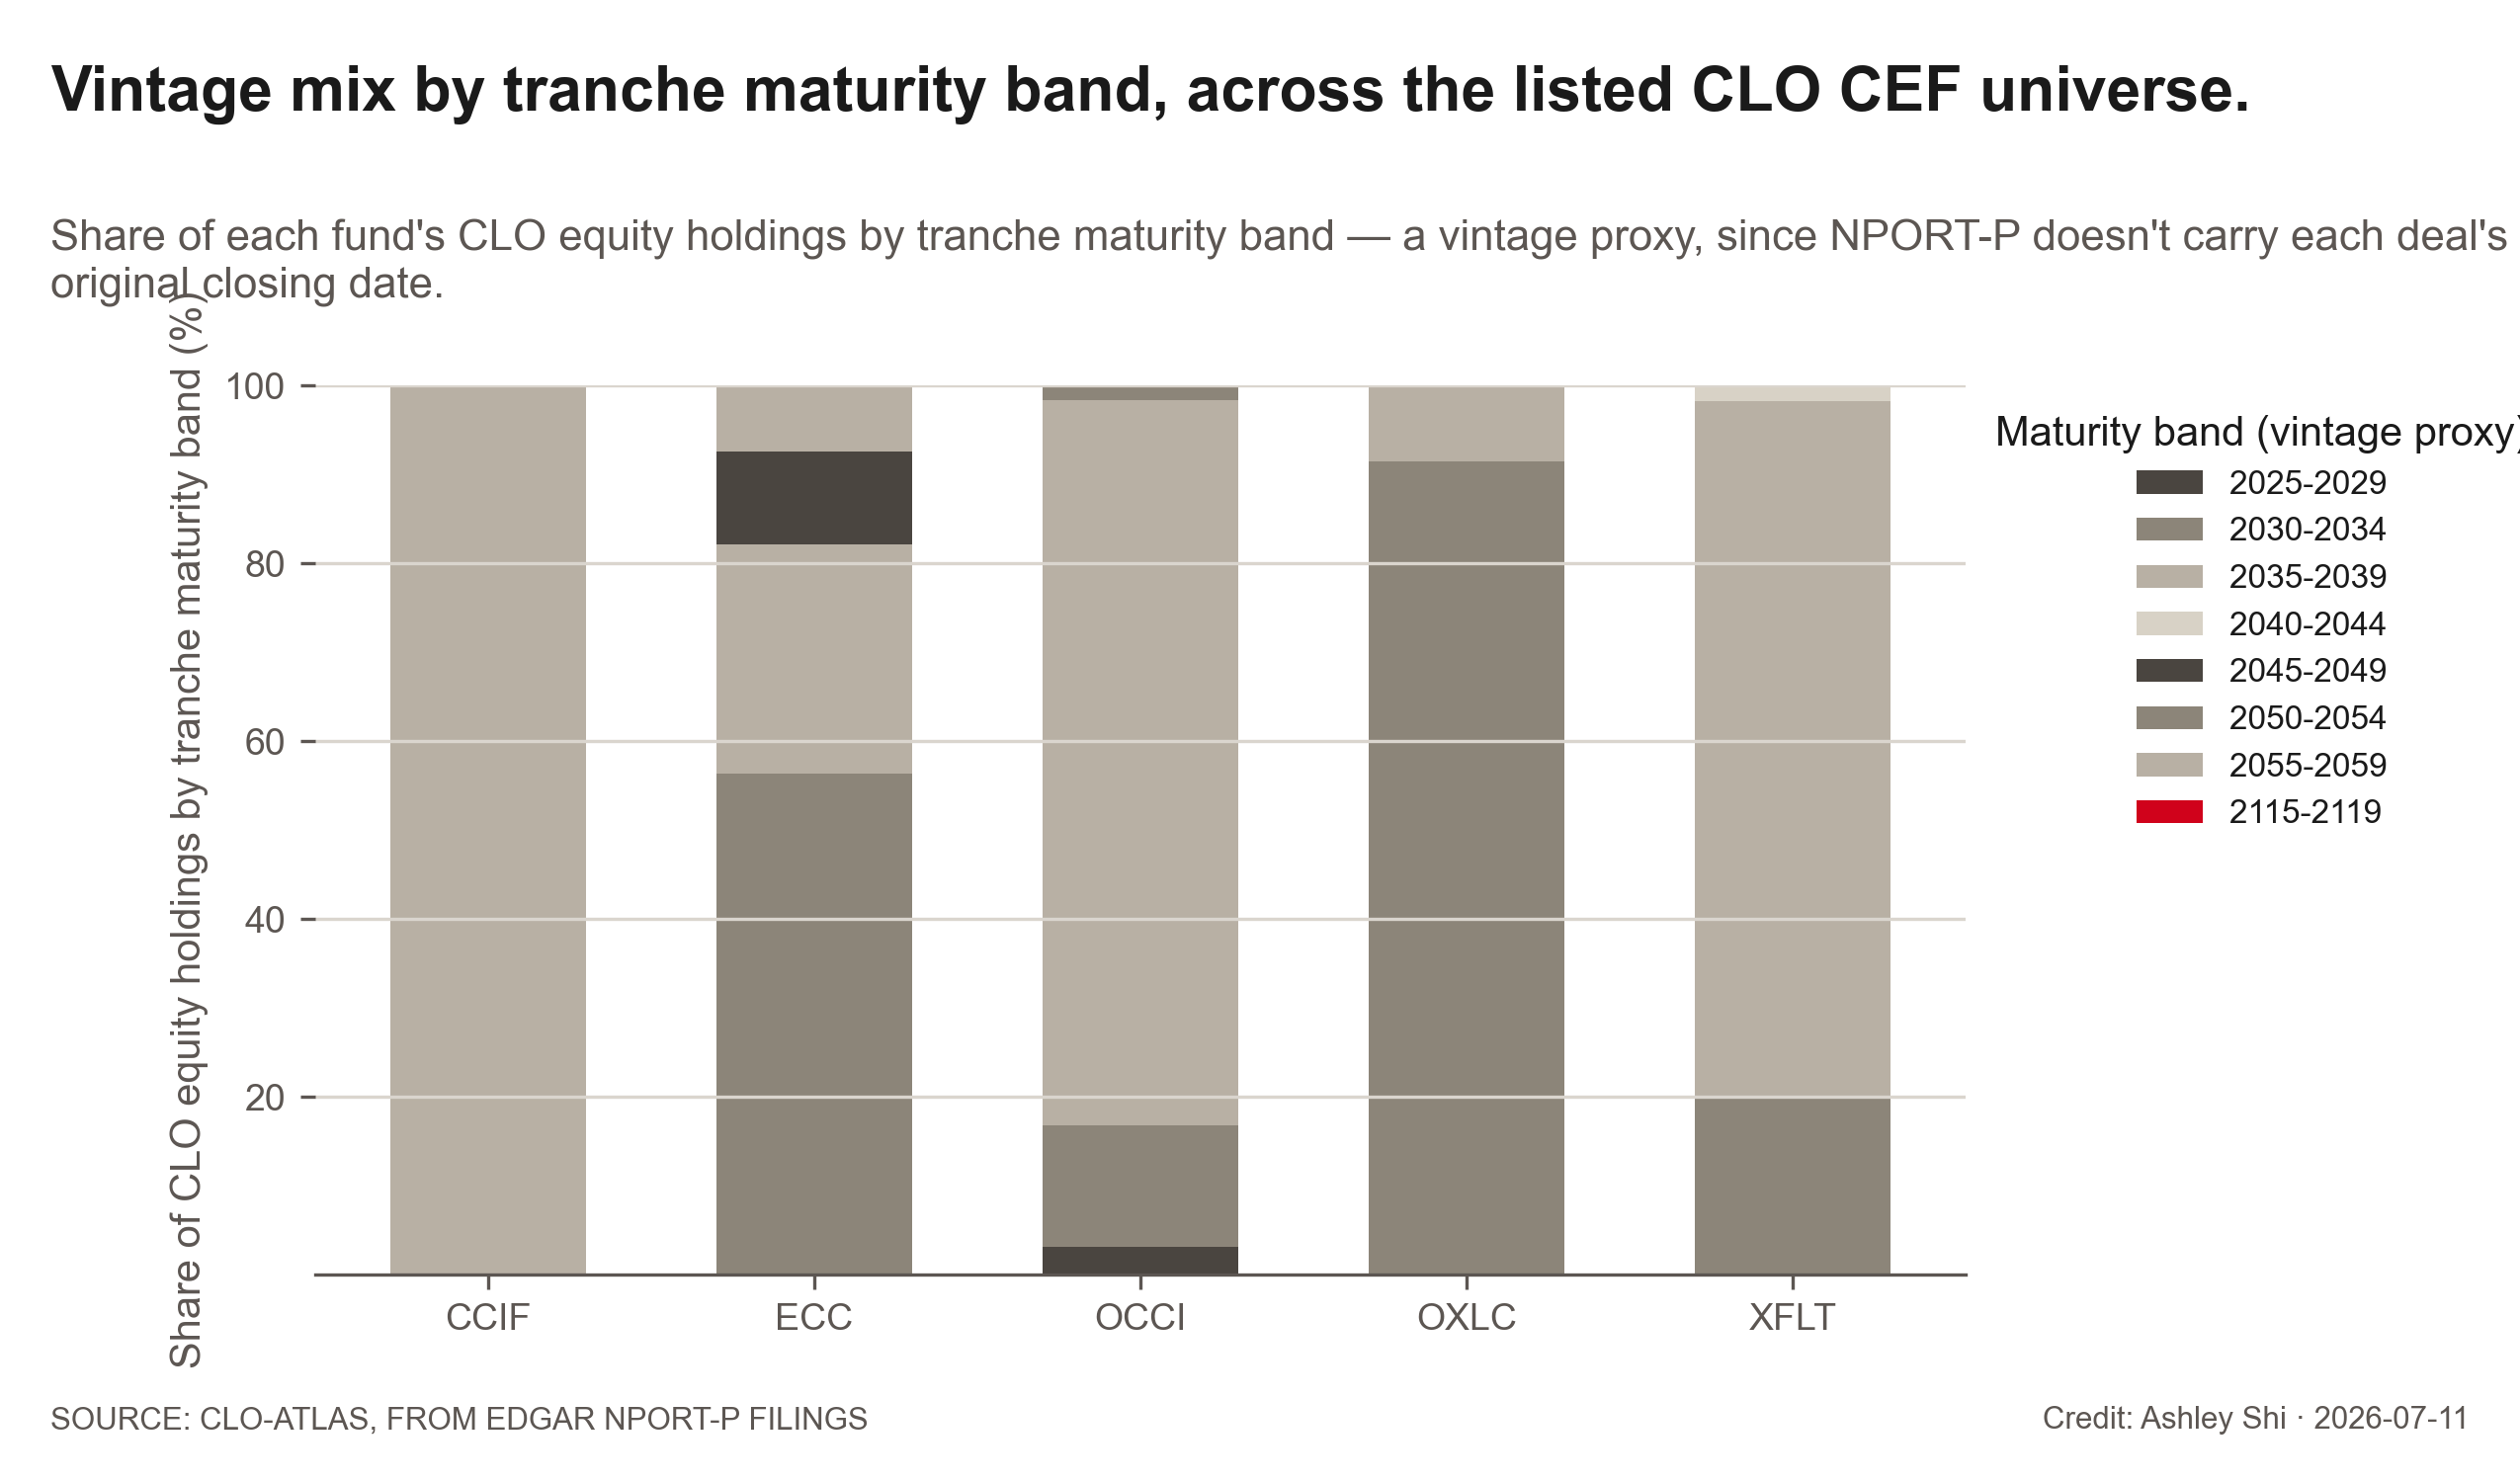

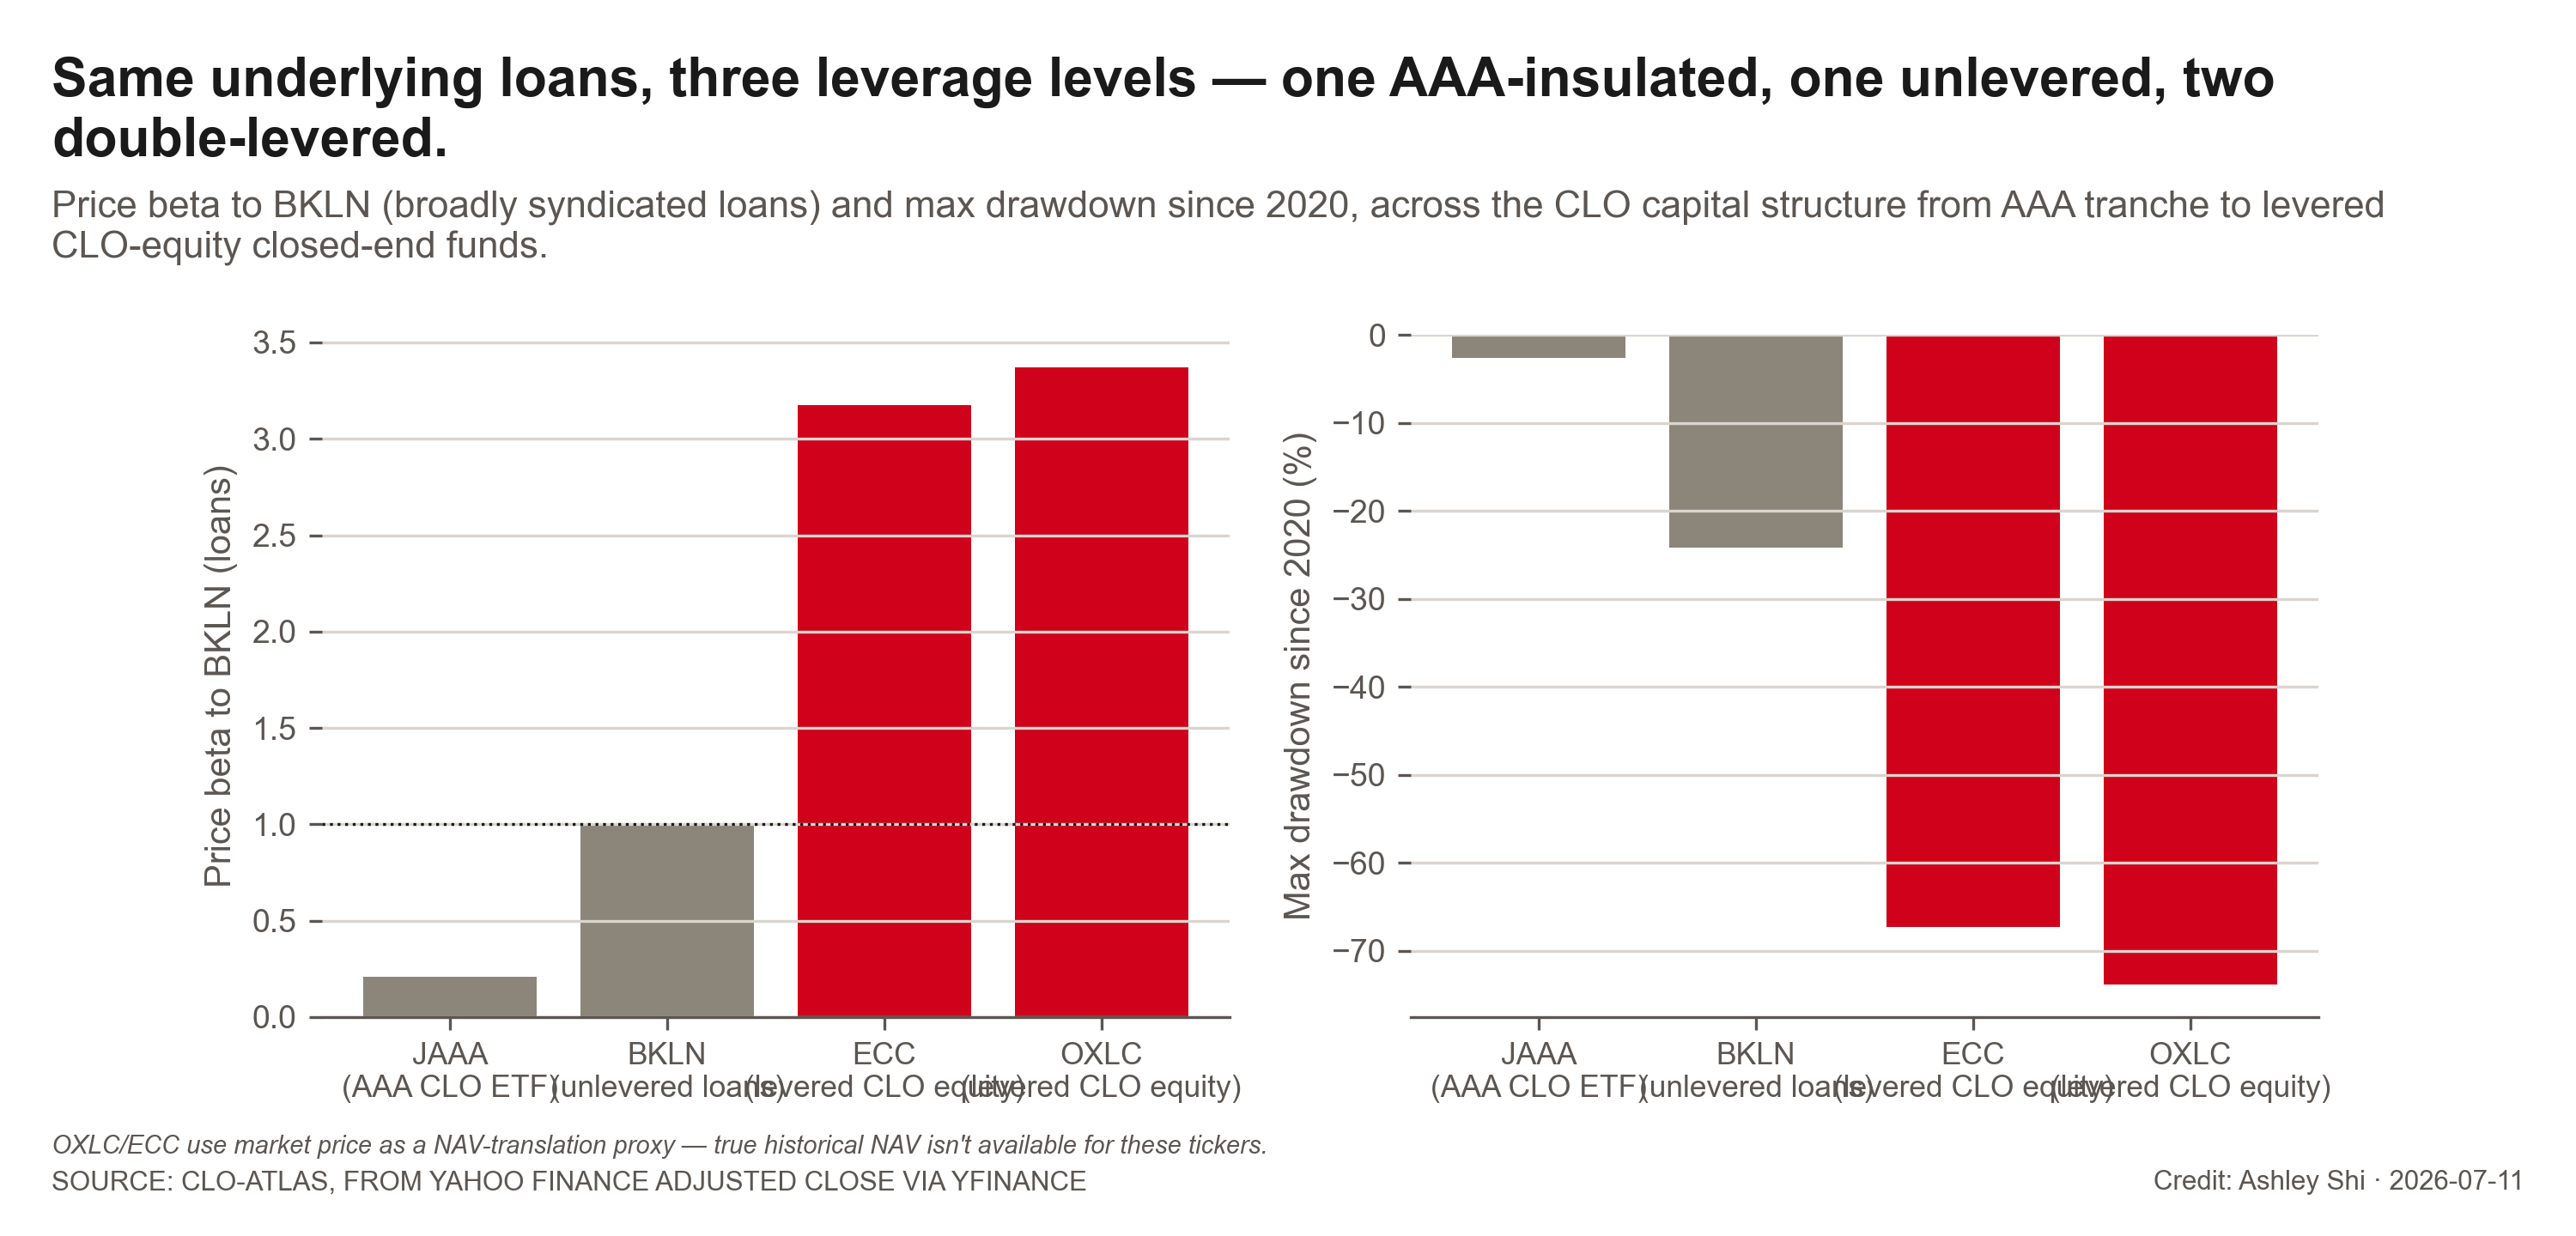

In [5]:
EXHIBITS = [
    "viz_flywheel",  # the centerpiece
    "viz_cost_of_capital_margin",
    "viz_distribution_cuts_vs_premium",
    "viz_shelf_concentration", "viz_vintage_mix",
    "viz_leverage_gradient",
]
for name in EXHIBITS:
    path = pathlib.Path("../figures") / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[skipped — not generated this run] {name}")


## VERIFIED / TO-VERIFY ledger

Every number appearing in this section's exhibits, including the split-adjustment bug fix and the demand-transmission chain's stated gap.

In [6]:
cef_deep_dive_ledger = ledger.run()
cef_deep_dive_ledger


,value,computation_or_citation,as_of,tag
0,"$2,351M raised via OXLC's ATM program since 2016",analysis_capital_machine.incremental_issuance(...,2025-06-11 00:00:00,VERIFIED
1,"Every disclosed premium is positive, range 2% ...","analysis_capital_machine.premium_history(), re...",n/a,VERIFIED
2,Bug caught and fixed: unrescaled comparison ag...,see analysis_capital_machine.py docstring and ...,n/a,VERIFIED
3,ECC: portfolio yield 9.8% vs. blended preferre...,analysis_cost_of_capital.cost_of_capital_margin(),n/a,VERIFIED
4,OXLC: portfolio yield 10.4% vs. blended prefer...,analysis_cost_of_capital.cost_of_capital_margin(),n/a,VERIFIED
5,JAAA: price beta to BKLN = 0.21,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
6,OXLC: price beta to BKLN = 3.37,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
7,ECC: price beta to BKLN = 3.17,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
8,BKLN: price beta to BKLN = 1.00,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
9,CCIF: >=5%-holder institutional floor 26.1%,"analysis_ownership.institutional_floor(), from...",n/a,VERIFIED
